In [41]:
!pip install torch torchvision matplotlib

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility at the very start - Single Source of Truth
torch.manual_seed(42)
np.random.seed(42)

In [43]:
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5, hidden_sizes=None):
        super(AblationMLP, self).__init__()
        # Default hidden sizes if not specified
        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]
        
        # flatten 32x32x3 -> 3072
        self.flatten = nn.Flatten()
        
        # manual linear layers: 3072 -> h1 -> h2 -> h3 -> 10
        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc4 = nn.Linear(hidden_sizes[2], 10)
        self.softmax = nn.Softmax(dim=1)
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
    
    def forward(self, x):
        x = self.flatten(x)
        
        # layer 1
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)
        
        # layer 2
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)
        
        # layer 3
        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)
        
        # output
        x = self.fc4(x)
        return x

In [44]:
# Data Optimization for Faster Training (Reduced Dataset: 500 images per class)
# Seed already set at import - ensure determinism
torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create reduced training set: 500 images per class (5,000 total) for faster training
torch.manual_seed(42)
reduce_train_size = int(0.1 * len(full_train_dataset))  # 5,000 images
full_train_reduced, _ = torch.utils.data.random_split(
    full_train_dataset, 
    [reduce_train_size, len(full_train_dataset) - reduce_train_size],
    generator=torch.Generator().manual_seed(42)
)

# Create train/val split: 90% train, 10% validation (Validation Split: Algorithm 7.2)
torch.manual_seed(42)
train_size = int(0.9 * len(full_train_reduced))
val_size = len(full_train_reduced) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_reduced,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training set size: {len(train_dataset)} (90% of reduced 5,000)")
print(f"Validation set size: {len(val_dataset)} (10% of reduced 5,000)")
print(f"Test set size: {len(test_dataset)} (Full CIFAR-10 test set)")
print(f"Data distribution: 500 images per class × 10 classes = 5,000 total training data")

Training set size: 4500 (90% of reduced 5,000)
Validation set size: 500 (10% of reduced 5,000)
Test set size: 10000 (Full CIFAR-10 test set)
Data distribution: 500 images per class × 10 classes = 5,000 total training data


In [45]:
# Setup device and hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
max_epochs = 50  # Increased to 50 for regularization ablation study

# Initialize overparameterized MLP (Architecture & Forward Pass: Algorithm 6.3)
# Hidden layers: [1024, 512, 256] - balanced architecture
model = AblationMLP(use_dropout=False, use_batchnorm=False, hidden_sizes=[1024, 512, 256]).to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Max Epochs: {max_epochs}")
print(f"Model: Overparameterized MLP [1024, 512, 256] - Baseline (No Regularization)")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Learning Rate: 0.01
Max Epochs: 50
Model: Overparameterized MLP [1024, 512, 256] - Baseline (No Regularization)
Total trainable parameters: 3,805,450


In [46]:
def evaluate(model, dataloader, device):
    """compute accuracy on a dataloader"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    model.train()
    return accuracy

def compute_loss(model, dataloader, loss_fn, device):
    """compute loss on a dataloader"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
    
    model.train()
    return total_loss / len(dataloader)

def train_epoch(model, train_loader, optimizer, loss_fn, device):
    """train for one epoch and return loss"""
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

# Early Stopping Class (Algorithm 7.1)
class EarlyStopping:
    """Early stopping to monitor validation loss and stop training if it plateaus"""
    def __init__(self, patience=7, verbose=False):
        self.patience = patience  # Number of epochs with no improvement after which training is stopped
        self.verbose = verbose
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [47]:
# Enhanced Training Loop with Early Stopping
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []

early_stopping = EarlyStopping(patience=7, verbose=True)
best_epoch = 0

for epoch in range(max_epochs):
    # Train for one epoch
    loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
    train_losses.append(loss)
    
    # Evaluate on train, validation, and test sets
    train_acc = evaluate(model, train_loader, device)
    val_loss = compute_loss(model, val_loader, loss_fn, device)
    val_acc = evaluate(model, val_loader, device)
    test_acc = evaluate(model, test_loader, device)
    
    # Store metrics
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    val_losses.append(val_loss)
    
    # Print epoch results
    print(f"Epoch {epoch+1:2d}/{max_epochs} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Test Acc: {test_acc:.2f}%")
    
    # Early Stopping Check (Algorithm 7.1)
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        best_epoch = epoch
        break
    best_epoch = epoch

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"Training stopped at epoch: {best_epoch + 1}/{max_epochs}")
print(f"\nFinal Metrics:")
print(f"  Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"  Val Accuracy:   {val_accuracies[-1]:.2f}%")
print(f"  Test Accuracy:  {test_accuracies[-1]:.2f}%")
print(f"\nGeneralization Gap Analysis:")
print(f"  Train-Val Gap:  {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print(f"  Train-Test Gap: {train_accuracies[-1] - test_accuracies[-1]:.2f}% ← Main Metric")
print("="*80)

Epoch  1/50 | Train Loss: 2.2930 | Val Loss: 2.2818 | Train Acc: 18.40% | Val Acc: 19.00% | Test Acc: 17.87%
Epoch  2/50 | Train Loss: 2.2668 | Val Loss: 2.2569 | Train Acc: 24.71% | Val Acc: 25.00% | Test Acc: 23.52%
Epoch  3/50 | Train Loss: 2.2346 | Val Loss: 2.2238 | Train Acc: 26.71% | Val Acc: 23.80% | Test Acc: 25.12%
Epoch  4/50 | Train Loss: 2.1931 | Val Loss: 2.1842 | Train Acc: 27.40% | Val Acc: 23.40% | Test Acc: 25.66%
Epoch  5/50 | Train Loss: 2.1475 | Val Loss: 2.1427 | Train Acc: 27.78% | Val Acc: 24.40% | Test Acc: 26.63%
Epoch  6/50 | Train Loss: 2.1038 | Val Loss: 2.1010 | Train Acc: 28.80% | Val Acc: 24.60% | Test Acc: 27.35%
Epoch  7/50 | Train Loss: 2.0610 | Val Loss: 2.0625 | Train Acc: 29.31% | Val Acc: 25.40% | Test Acc: 27.90%
Epoch  8/50 | Train Loss: 2.0266 | Val Loss: 2.0260 | Train Acc: 30.78% | Val Acc: 26.60% | Test Acc: 28.79%
Epoch  9/50 | Train Loss: 1.9840 | Val Loss: 1.9919 | Train Acc: 31.60% | Val Acc: 26.80% | Test Acc: 29.52%
Epoch 10/50 | Train

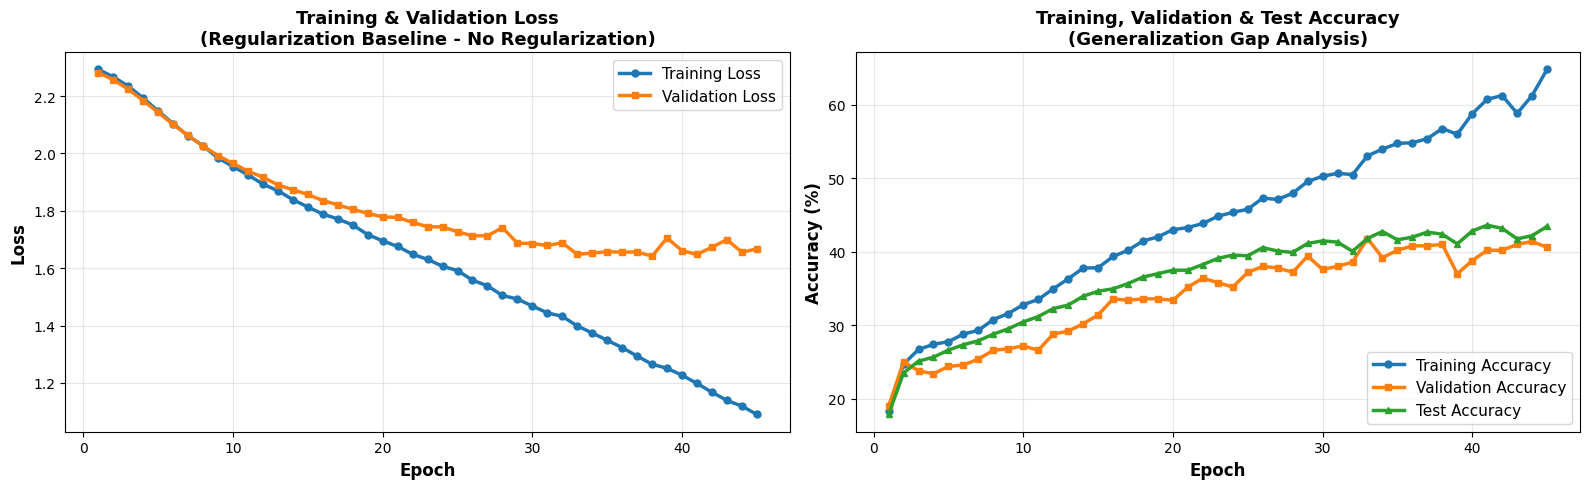


GENERALIZATION GAP ANALYSIS
Accuracy at Final Epoch (45):
  Training Accuracy:  64.80%
  Validation Accuracy:  40.60%
  Test Accuracy:  43.44%

Generalization Gap (Overfitting Measure):
  Train-Validation Gap:  24.20%


In [ ]:
# Metrics & Visualization: Dual-Axis Plots for Clear Gap Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

num_epochs = len(train_losses)
epochs_range = range(1, num_epochs + 1)

# Plot 1: Loss Curves (Train vs Val)
ax1.plot(epochs_range, train_losses, 'o-', label='Training Loss', linewidth=2.5, markersize=5, color='#1f77b4')
ax1.plot(epochs_range, val_losses, 's-', label='Validation Loss', linewidth=2.5, markersize=5, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss\n(Regularization Baseline - No Regularization)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy Curves (Train vs Val vs Test)
ax2.plot(epochs_range, train_accuracies, 'o-', label='Training Accuracy', linewidth=2.5, markersize=5, color='#1f77b4')
ax2.plot(epochs_range, val_accuracies, 's-', label='Validation Accuracy', linewidth=2.5, markersize=5, color='#ff7f0e')
ax2.plot(epochs_range, test_accuracies, '^-', label='Test Accuracy', linewidth=2.5, markersize=5, color='#2ca02c')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training, Validation & Test Accuracy\n(Generalization Gap Analysis)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gap Analysis Summary (Visualization & Metrics)
print("GENERALIZATION GAP ANALYSIS")
print("="*80)
final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]
final_test_acc = test_accuracies[-1]

train_val_gap = final_train_acc - final_val_acc
train_test_gap = final_train_acc - final_test_acc

print(f"Accuracy at Final Epoch ({num_epochs}):")
print(f"  Training Accuracy: {final_train_acc:6.2f}%")
print(f"  Validation Accuracy: {final_val_acc:6.2f}%")
print(f"  Test Accuracy: {final_test_acc:6.2f}%")
print(f"\nGeneralization Gap (Overfitting Measure):")
print(f"  Train-Validation Gap: {train_val_gap:6.2f}%")


This is when no regularization ,early stopping,and noise is applied 
